# Visualizer: Comprehensive Scale-over-Preference Outcomes (Figure 2)
---
**Context:** This notebook generates the 3x3 multi-panel Figure 2, integrating empirical evidence across multiple operationalizations:
* **(a)** Initial visibility allocation (CCDFs).
* **(b)** Dynamic adjustments to supply scale (Granger causality & Exposure Tiers).
* **(c)** Scale-over-Preference dual moderation (Partial Residuals).
* **(d)** Supply scale elasticity on Creator Engagement Returns.
* **(e)** Supply scale elasticity on Consumer Engagement Depth.
* **(f)** Distribution mechanism intervention (Individual vs. Population Feedback).

### Step 1: Environment & Global Configurations
Loading required libraries and establishing the `scienceplots` Nature-style aesthetic.

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Dict, List, Optional, Any

import warnings
warnings.filterwarnings('ignore')
os.environ['SEABORN_RC'] = 'False'

import scienceplots
plt.style.use('nature')

# Global Font and Plot Settings
BASE_FONTSIZE = 14
TICK_FONTSIZE = BASE_FONTSIZE - 1
TITLE_FONTSIZE = BASE_FONTSIZE + 1

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': BASE_FONTSIZE,
    'axes.titlesize': TITLE_FONTSIZE,
    'axes.labelsize': BASE_FONTSIZE,
    'xtick.labelsize': TICK_FONTSIZE,
    'ytick.labelsize': TICK_FONTSIZE,
    'legend.fontsize': TICK_FONTSIZE,
    'figure.dpi': 150,
    'axes.unicode_minus': False,
    'axes.linewidth': 0.8,
})

### Step 2: Data Processing Pipeline
Defining functions to safely extract and structure data from the `.pkl` models.

In [2]:
def process_fig2a_data(result_file='fig_results_2.2a.pkl'):
    if not os.path.exists(result_file): return None
    with open(result_file, 'rb') as f: res = pickle.load(f)
    raw_dict = res['ci_results_raw']
    coeffs, ci_low, ci_high, lag_order = [], [], [], []
    
    for k in sorted(raw_dict.keys()):
        if k.startswith('x_main_lag'):
            lag_order.append(int(re.search(r'\d+', k).group()))
            coeffs.append(raw_dict[k]['beta_hat'])
            ci_low.append(raw_dict[k]['ci_percentile'][0])
            ci_high.append(raw_dict[k]['ci_percentile'][1])
            
    coeffs, ci_low, ci_high, lags = map(lambda x: np.array(x)[::-1], [coeffs, ci_low, ci_high, lag_order])
    return {
        'lags': lags, 'coeffs': coeffs, 'ci_low': ci_low, 'ci_high': ci_high,
        'yerr_lower': coeffs - ci_low, 'yerr_upper': ci_high - coeffs,
        'p_boot': res['p_boot']
    }

def process_fig2b_data(pkl_files=['fig_results_2.2_ge1000.pkl', 'fig_results_2.2_ge100.pkl', 'fig_results_2.2_ge10.pkl', 'fig_results_2.2_lt10.pkl']):
    categories = ['ge1000', 'ge100', 'ge10', 'lt10']
    sum_beta_list, ci_low_list, ci_high_list = [], [], []
    for file in pkl_files:
        if not os.path.exists(file):
            sum_beta_list.append(np.nan); ci_low_list.append(np.nan); ci_high_list.append(np.nan)
            continue
        with open(file, 'rb') as f: res = pickle.load(f)
        beta = res['final_model'].params.get('scale_aigc', np.nan)
        boot_res = res.get('bootstrap_results', {}).get('scale_aigc', {})
        ci = boot_res.get('ci_bca', boot_res.get('ci_percentile', [np.nan, np.nan]))
        sum_beta_list.append(beta); ci_low_list.append(ci[0]); ci_high_list.append(ci[1])
        
    return {'categories': categories, 'y_pos': np.arange(len(categories)), 'sum_beta': sum_beta_list, 'ci_low': ci_low_list, 'ci_high': ci_high_list}

def process_fig2c_data(result_file='fig_results_2.3.pkl'):
    if not os.path.exists(result_file): return None
    with open(result_file, 'rb') as f: res = pickle.load(f)
    fig2c_data = []
    for var_name in res.get('custom_endog_vars', [])[:2]:
        if var_name not in res['partial_residuals']: continue
        partial = res['partial_residuals'][var_name]
        partial_model = sm.OLS(partial['resid_y'], sm.add_constant(partial['resid_x'])).fit()
        boot_res = res.get('bootstrap_results', {}).get(var_name, {})
        ci = boot_res.get('ci_bca', boot_res.get('ci_percentile', [np.nan, np.nan]))
        fig2c_data.append({
            'resid_x': partial['resid_x'], 'resid_y': partial['resid_y'],
            'beta_partial': partial_model.params[1] if len(partial_model.params)>1 else partial_model.params[0],
            'ci': ci, 'p_value': partial_model.pvalues[1] if len(partial_model.pvalues)>1 else partial_model.pvalues[0]
        })
    return fig2c_data

def process_fig2d_data(creator_files, consumer_files):
    def _extract(files):
        items = []
        for f_name in files:
            if not os.path.exists(f_name): continue
            with open(f_name, 'rb') as f: res = pickle.load(f)
            var = res.get('custom_endog_vars', [''])[0]
            boot = res.get('bootstrap_results', {}).get(var, {})
            items.append({
                'beta': res['final_model'].params.get(var, np.nan),
                'ci': boot.get('ci_bca', boot.get('ci_percentile', [np.nan, np.nan]))
            })
        return {'items': items} if items else None
    
    return {'a': _extract(creator_files), 'b': _extract(consumer_files)}


### Step 3: Load & Parse All Required Artifacts
This step safely computes the required CCDF metrics (`play_31d`, `time_to_90_percent`) before plotting.

In [3]:
video_dir = './'
try:
    main_df = pd.read_parquet(os.path.join(video_dir, 'item_v5.parquet'))      
    daily_click = pd.read_parquet(os.path.join(video_dir, 'item_exposure.parquet'))
    daily_click['photo_id'] = daily_click['photo_id'].astype('int64')
    daily_click = daily_click.apply(pd.to_numeric, errors='coerce')
    item_df = main_df.merge(daily_click, on='photo_id', how='left').fillna(0)
    
    # ✅ FIXED: Compute required plotting metrics for Panel (a)
    pure_play_cols = [f"play_day_{i}" for i in range(1, 32)]
    valid_cols = [c for c in pure_play_cols if c in item_df.columns]
    
    if valid_cols:
        item_df['play_31d'] = item_df[valid_cols].sum(axis=1)
        item_df['total_plays'] = item_df['play_31d']
        cumulative_plays = item_df[valid_cols].cumsum(axis=1)
        item_df["time_to_90_percent"] = (
            cumulative_plays.ge(item_df["total_plays"] * 0.9, axis=0)
            .idxmax(axis=1).str.replace("play_day_", "")
            .astype(float).fillna(0).astype(int)
        )
    else:
        item_df['play_31d'] = 0
        item_df["time_to_90_percent"] = 0
        
    print("✅ Video data loaded and metrics computed successfully!")
except Exception as e:
    print(f"⚠️ Error loading data: {e}")
    item_df = pd.DataFrame()

processed_data = {
    'fig2a': process_fig2a_data(),
    'fig2b': process_fig2b_data(),
    'fig2c': process_fig2c_data(),
    'fig2d': process_fig2d_data(
        ['fig_results_2.4_creator_com_scale_aigc.pkl', 'fig_results_2.4_creator_com_scale_hgc.pkl',
         'fig_results_2.4_creator_val_scale_aigc.pkl', 'fig_results_2.4_creator_val_scale_hgc.pkl'],
        ['fig_results_2.4_consumer_com_scale_aigc.pkl', 'fig_results_2.4_consumer_com_scale_hgc.pkl',
         'fig_results_2.4_consumer_val_scale_aigc.pkl', 'fig_results_2.4_consumer_val_scale_hgc.pkl']
    )
}
print("✅ DOLS model artifacts parsed.")

✅ Video data loaded and metrics computed successfully!
✅ DOLS model artifacts parsed.


### Step 4: Multi-Panel Visualization (Figure 2 3x3 Grid)

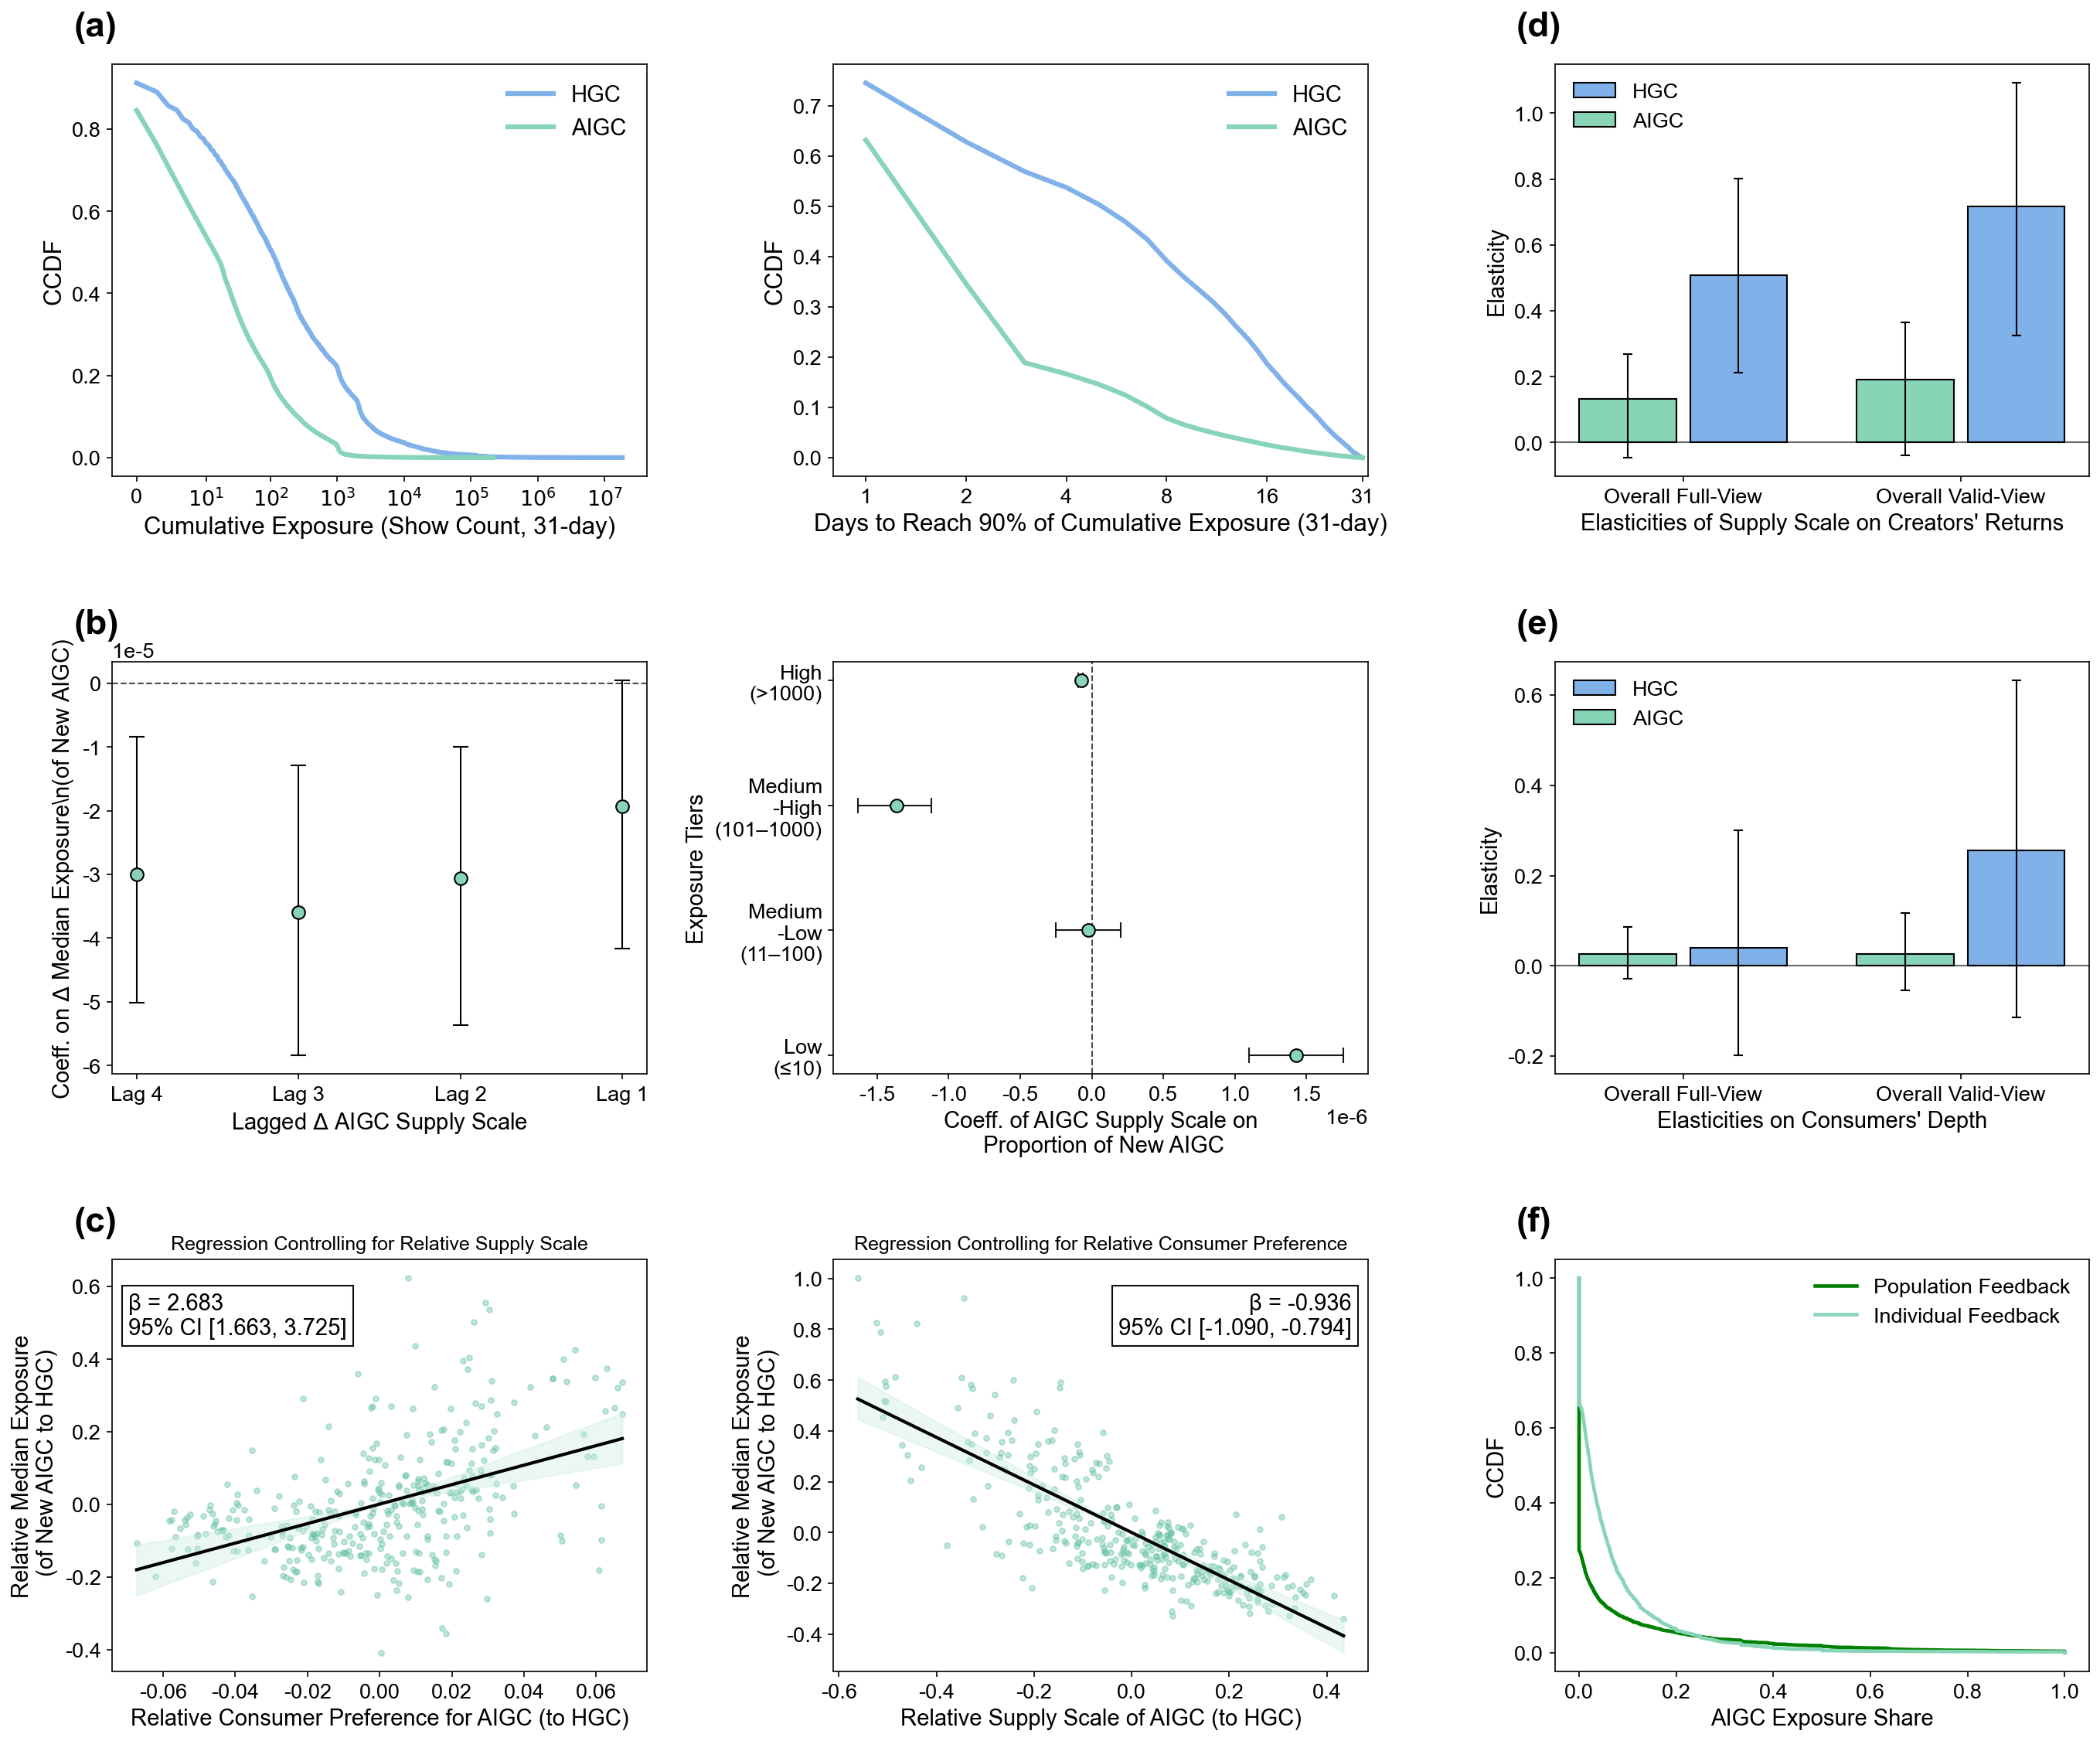

🎉 Figure 2 successfully generated and saved as fig2.pdf!


In [10]:
fig = plt.figure(figsize=(22, 18), dpi=150)
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(3)]

# ==========================================
# PANEL (a): CCDFs 
# ==========================================
def get_ccdf(data_series):
    if data_series.empty or data_series.max() == 0: return np.array([0]), np.array([1])
    vc = data_series.value_counts().sort_index()
    vc_df = pd.DataFrame({'value': vc.index, 'count': vc.values})
    vc_df['count'] = vc_df['count'] / vc_df['count'].sum()
    return vc_df['value'].values, 1 - vc_df['count'].cumsum().values

for idx, metric, name in [(0, "play_31d", "Cumulative Exposure (Show Count, 31-day)"), 
                          (1, "time_to_90_percent", "Days to Reach 90% of Cumulative Exposure (31-day)")]:
    ax = axes[0][idx]
    for label, is_aigc, col in [("HGC", 0, "#81b1e9"), ("AIGC", 1, "#88d4b7")]:
        x, y = get_ccdf(item_df.loc[item_df["photo_is_aigc_photo"] == is_aigc, metric])
        ax.plot(x, y, color=col, lw=3.0, label=label)
    
    ax.set_xlabel(name, fontsize=BASE_FONTSIZE + 1)
    ax.set_ylabel("CCDF", fontsize=BASE_FONTSIZE + 1)
    ax.legend(loc='upper right', frameon=False, fontsize=BASE_FONTSIZE)
    
    if idx == 0:
        ax.set_xscale('function', functions=(lambda x: np.log10(x + 1), lambda y: 10**y - 1))
        xmax = item_df["play_31d"].max()
        if xmax > 0:
            ticks = [0] + [10**i for i in range(1, int(np.log10(xmax)) + 2) if 10**i <= xmax * 1.2]
            ax.set_xticks(ticks)
            ax.set_xticklabels(['0'] + [f'$10^{{{int(np.log10(t))}}}$' for t in ticks[1:]])
    else:
        ax.set_xscale('log', base=2)
        ax.set_xlim(0.8, 32.2)
        ax.set_xticks([1, 2, 4, 8, 16, 31])
        ax.set_xticklabels([1, 2, 4, 8, 16, 31])

# ==========================================
# PANEL (b): Granger & Exposure Tiers 
# ==========================================
ax_granger = axes[1][0] 
if processed_data.get('fig2a'):
    d = processed_data['fig2a']
    yerr = np.array([d['yerr_lower'], d['yerr_upper']])
    ax_granger.errorbar(d['lags'], d['coeffs'], yerr=yerr, fmt='o', color='#88d4b7', ecolor='black', capsize=5)
    ax_granger.scatter(d['lags'], d['coeffs'], color='#88d4b7', s=64, edgecolors='black', zorder=4)
    ax_granger.axhline(0, color='black', linestyle='--', alpha=0.7)
    ax_granger.set_xticks(d['lags'])
    ax_granger.set_xticklabels(['Lag 4','Lag 3','Lag 2','Lag 1'][::-1])
    ax_granger.set_ylabel(r"Coeff. on $\Delta$ Median Exposure\n(of New AIGC)")
    ax_granger.set_xlabel(r'Lagged $\Delta$ AIGC Supply Scale')

ax_tiers = axes[1][1]
if processed_data.get('fig2b'):
    d = processed_data['fig2b']
    xerr = np.array([np.array(d['sum_beta']) - np.array(d['ci_low']), np.array(d['ci_high']) - np.array(d['sum_beta'])])
    ax_tiers.errorbar(d['sum_beta'], d['y_pos'], xerr=xerr, fmt='none', ecolor='black', capsize=5, alpha=0.9)
    ax_tiers.scatter(d['sum_beta'], d['y_pos'], color="#88d4b7", s=64, edgecolors='black', zorder=4)
    ax_tiers.axvline(0, color='black', linestyle='--', alpha=0.7)
    ax_tiers.set_yticks(d['y_pos'])
    ax_tiers.set_yticklabels(['High\n(>1000)', 'Medium\n-High\n(101–1000)', 'Medium\n-Low\n(11–100)', 'Low\n(≤10)'])
    ax_tiers.invert_yaxis()
    ax_tiers.set_ylabel("Exposure Tiers")
    ax_tiers.set_xlabel("Coeff. of AIGC Supply Scale on\n Proportion of New AIGC")

# ==========================================
# PANEL (c): Partial Residuals 
# ==========================================
titles = ["Regression Controlling for Relative Consumer Preference", "Regression Controlling for Relative Supply Scale"][::-1]
xlabels = ["Relative Consumer Preference for AIGC (to HGC)", "Relative Supply Scale of AIGC (to HGC)"]
for j in range(2):
    ax = axes[2][j]
    if processed_data.get('fig2c') and len(processed_data['fig2c']) > j:
        d = processed_data['fig2c'][j]
        x, y = d['resid_x'], d['resid_y']
        ax.scatter(x, y, s=11, alpha=0.4, color=['#66c2a5', '#66c2a5'][j])
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, d['beta_partial'] * xline, color='black', lw=2.0)
        ax.fill_between(xline, d['ci'][0]*xline, d['ci'][1]*xline, color=['#ccece6', '#ccece6'][j], alpha=0.4)
        ax.set_title(titles[j], fontsize=BASE_FONTSIZE-2)
        ax.set_xlabel(xlabels[j])
        ax.set_ylabel("Relative Median Exposure\n (of New AIGC to HGC)")
        ax.text(0.97 if j==1 else 0.03, 0.92, f"β = {d['beta_partial']:.3f}\n95% CI [{d['ci'][0]:.3f}, {d['ci'][1]:.3f}]",
                transform=ax.transAxes, ha='right' if j==1 else 'left', va='top', bbox=dict(facecolor='white', alpha=0.95))

# ==========================================
# PANELS (d) & (e): Elasticities Bar Plots 
# ==========================================
for j, key in enumerate(['a', 'b']):
    ax = axes[j][2]
    group = processed_data.get('fig2d', {}).get(key)
    if group and group['items']:
        items = group['items']
        for g, offset in [('HGC', 0.2), ('AIGC', -0.2)]:
            idx = [1, 3] if g == 'HGC' else [0, 2]
            means = [items[i]['beta'] for i in idx[::-1]]
            cis = [items[i]['ci'] for i in idx[::-1]]
            yerr = [[m - c[0] for m, c in zip(means, cis)], [c[1] - m for m, c in zip(means, cis)]]
            xpos = np.arange(2) + offset
            ax.bar(xpos, means, width=0.35, color="#81b1e9" if g == 'HGC' else "#88d4b7", edgecolor='black', label=g)
            ax.errorbar(xpos, means, yerr=yerr, fmt='none', ecolor='black', capsize=3)
        
        ax.set_xlabel('Elasticities of Supply Scale on Creators\' Returns' if key == 'a' else 'Elasticities on Consumers\' Depth')
        ax.set_xticks(np.arange(2))
        ax.set_xticklabels(['Overall Full-View', 'Overall Valid-View'])
        ax.legend(frameon=False)
        ax.axhline(0, color='black', alpha=0.6)
        ax.set_ylabel("Elasticity")

# ==========================================
# PANEL (f): New Subfigure - Distribution Algorithm comparison CCDF 
# ==========================================
ax_f = axes[2][2]
try:
    matched_data = pd.read_parquet('./match45.parquet')
    df_treat = matched_data[matched_data['is_set_close_personalise_reco'] == 0]
    df_control = matched_data[matched_data['is_set_close_personalise_reco'] == 1]
    
    for df_ in [df_treat, df_control]:
        df_["fut56_aigc_ratio"] = df_["fut56_aigc_play_cnt"] / (df_["fut56_aigc_play_cnt"] + df_["fut56_hgc_play_cnt"])
    
    for name, series, color in [("Population Feedback", df_control["fut56_aigc_ratio"].dropna(), "green"), 
                                ("Individual Feedback", df_treat["fut56_aigc_ratio"].dropna(), "#88d4b7")]:
        s_vals = np.sort(series)
        ax_f.plot(s_vals, 1 - np.arange(1, len(s_vals) + 1) / len(s_vals), color=color, lw=2.2, label=name)
    
    ax_f.set_xlabel("AIGC Exposure Share")
    ax_f.set_ylabel("CCDF")
    ax_f.legend(frameon=False)
except Exception as e:
    ax_f.text(0.5, 0.5, f"Data missing\n{e}", ha='center', va='center')

# ==========================================
# Annotations & Output
# ==========================================
plt.tight_layout(rect=[0, 0.02, 1, 0.96])

def add_label(ax_group, label):
    bboxes = [ax.get_position() for ax in ax_group]
    fig.text(min(bb.x0 for bb in bboxes) - 0.015, max(bb.y1 for bb in bboxes) + 0.01, label,
             fontsize=22, fontweight='bold', fontfamily='Arial', ha='left', va='bottom')

add_label([axes[0][0], axes[0][1]], "(a)")
add_label([axes[1][0], axes[1][1]], "(b)")
add_label([axes[2][0], axes[2][1]], "(c)")
add_label([axes[0][2]], "(d)")
add_label([axes[1][2]], "(e)")
add_label([axes[2][2]], "(f)")

plt.savefig('fig2.pdf', dpi=1200, bbox_inches='tight', pad_inches=0.05)
plt.show()
print("🎉 Figure 2 successfully generated and saved as fig2.pdf!")